In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [65]:
ruta_csv = Path(r"X:\Proyectos Python\MODULO 5 HENRY\PI\Proyecto-Integrador-M5\Base_de_datos.csv")

df = pd.read_csv(ruta_csv)

df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [66]:
# =========================================================

df.shape

(10763, 23)

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   fecha_prestamo                 10763 non-null  str    
 2   capital_prestado               10763 non-null  float64
 3   plazo_meses                    10763 non-null  int64  
 4   edad_cliente                   10763 non-null  int64  
 5   tipo_laboral                   10763 non-null  str    
 6   salario_cliente                10763 non-null  int64  
 7   total_otros_prestamos          10763 non-null  int64  
 8   cuota_pactada                  10763 non-null  int64  
 9   puntaje                        10763 non-null  float64
 10  puntaje_datacredito            10757 non-null  float64
 11  cant_creditosvigentes          10763 non-null  int64  
 12  huella_consulta                10763 non-null  int64  
 1

In [68]:
df.nunique()

tipo_credito                         6
fecha_prestamo                   10758
capital_prestado                  7306
plazo_meses                         18
edad_cliente                        54
tipo_laboral                         2
salario_cliente                   1385
total_otros_prestamos             1538
cuota_pactada                     9836
puntaje                            248
puntaje_datacredito                315
cant_creditosvigentes               39
huella_consulta                     28
saldo_mora                          55
saldo_total                       8858
saldo_principal                   8647
saldo_mora_codeudor                  4
creditos_sectorFinanciero           33
creditos_sectorCooperativo          11
creditos_sectorReal                 24
promedio_ingresos_datacredito     5309
tendencia_ingresos                  46
Pago_atiempo                         2
dtype: int64

In [69]:
df.isnull().sum()

tipo_credito                        0
fecha_prestamo                      0
capital_prestado                    0
plazo_meses                         0
edad_cliente                        0
tipo_laboral                        0
salario_cliente                     0
total_otros_prestamos               0
cuota_pactada                       0
puntaje                             0
puntaje_datacredito                 6
cant_creditosvigentes               0
huella_consulta                     0
saldo_mora                        156
saldo_total                       156
saldo_principal                   405
saldo_mora_codeudor               590
creditos_sectorFinanciero           0
creditos_sectorCooperativo          0
creditos_sectorReal                 0
promedio_ingresos_datacredito    2930
tendencia_ingresos               2932
Pago_atiempo                        0
dtype: int64

In [70]:
# ================================================
# RESUMEN TÉCNICO DE COLUMNAS
# ================================================

columnas_resumen = pd.DataFrame({
    "columna": df.columns,
    "tipo_actual": df.dtypes.astype(str).values,
    "valores_unicos": df.nunique().values,
    "nulos": df.isnull().sum().values,
    "porcentaje_nulos": (df.isnull().mean().values * 100).round(2)

})
columnas_resumen

,columna,tipo_actual,valores_unicos,nulos,porcentaje_nulos
0,tipo_credito,int64,6,0,0.00
1,fecha_prestamo,str,10758,0,0.00
2,capital_prestado,float64,7306,0,0.00
3,plazo_meses,int64,18,0,0.00
4,edad_cliente,int64,54,0,0.00
5,tipo_laboral,str,2,0,0.00
6,salario_cliente,int64,1385,0,0.00
7,total_otros_prestamos,int64,1538,0,0.00
8,cuota_pactada,int64,9836,0,0.00
9,puntaje,float64,248,0,0.00


In [71]:
# ================================================
# CLASIFICACIÓN AUTOMÁTICA INICIAL DE VARIABLES
# ================================================

columnas_numericas = df.select_dtypes(include=["int64","float64"]).columns.tolist()
columnas_categoricas = df.select_dtypes(include=["object", "category"]).columns.tolist()
columnas_booleanas = df.select_dtypes(include=[bool]).columns.tolist()

columnas_dicotomicas = [col for col in df.columns if df[col].nunique(dropna=True) == 2]
columnas_politomicas = [
    col for col in columnas_categoricas 
    if df[col].nunique(dropna=True) > 2
]

posibles_identificadores = [
    col for col in df.columns 
    if df[col].nunique(dropna=True) == df.shape[0]
]

print("Variables numéricas:", columnas_numericas)
print("Variables categóricas:", columnas_categoricas)
print("Variables booleanas:", columnas_booleanas)
print("Variables dicotómicas:", columnas_dicotomicas)
print("Variables politómicas:", columnas_politomicas)
print("Posibles identificadores:", posibles_identificadores)

Variables numéricas: ['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito', 'Pago_atiempo']
Variables categóricas: ['fecha_prestamo', 'tipo_laboral', 'tendencia_ingresos']
Variables booleanas: []
Variables dicotómicas: ['tipo_laboral', 'Pago_atiempo']
Variables politómicas: ['fecha_prestamo', 'tendencia_ingresos']
Posibles identificadores: []


C:\Users\Kiih\AppData\Local\Temp\ipykernel_18624\1960625062.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [72]:
# ================================================
# REVISIÓN DE VALORES NULOS 
# ================================================

#Se calcula la cantidad y el porcentaje de valores nulos por columna.
# Esto permite identificar qué variables presentan problemas de completitud
# y qué tan relevante es el faltante dentro del dataset.

nulos = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "porcentaje_nulos": (df.isnull().mean() *100).round(2)
}).sort_values(by="porcentaje_nulos", ascending=False)
               
nulos[nulos["nulos"]> 0]

,nulos,porcentaje_nulos
tendencia_ingresos,2932,27.24
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06


In [73]:
# Se revisan posibles representaciones alternativas de valores nulos en columnas de texto, como cadenas vacías, "NA", "N/A", "null",
# "None", "-", "?" o expresiones similares.

valores_nulos_equivalentes = [   
    "", " ", "NA", "N/A", "na", "n/a",
    "null", "Null", "NULL",
    "None", "none",
    "-", "?",
    "Sin dato", "sin dato"
]

conteo_nulos_equivalentes = {}

for col in df.select_dtypes(include=["object"]).columns:
    conteo = df[col].isin(valores_nulos_equivalentes).sum()

    if conteo > 0:
        conteo_nulos_equivalentes[col] = conteo

conteo_nulos_equivalentes

C:\Users\Kiih\AppData\Local\Temp\ipykernel_18624\3812609434.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:


{}

In [74]:
df_limpio = df.copy()

In [75]:
df_limpio = df_limpio.replace(valores_nulos_equivalentes, np.nan)

In [76]:
nulos_post = pd.DataFrame({
    "nulos": df_limpio.isnull().sum(),
    "porcentaje_nulos": (df_limpio.isnull().mean() * 100).round(2)
}).sort_values(by="porcentaje_nulos", ascending=False)

nulos_post[nulos_post["nulos"] > 0]

,nulos,porcentaje_nulos
tendencia_ingresos,2932,27.24
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06


In [77]:
# Se revisan columnas constantes y posibles identificadores únicos.
# Las columnas constantes no aportan variabilidad al análisis.
# Los identificadores únicos pueden servir para trazabilidad, pero normalmente no aportan valor predictivo directo al modelo.


columnas_constantes = [
    col for col in df_limpio.columns
    if df_limpio[col].nunique(dropna=True) <= 1
]

posibles_identificadores = [
    col for col in df_limpio.columns
    if df_limpio[col].nunique(dropna=True) == df_limpio.shape[0]
]

print("Columnas constantes:", columnas_constantes)
print("Posibles identificadores únicos:", posibles_identificadores)

Columnas constantes: []
Posibles identificadores únicos: []


In [78]:
# ================================================
# CONVERSIÓN Y CORRECCIÓN DE TIPOS DE DATOS
# ================================================

# Se revisan los tipos de datos actuales antes de aplicar conversiones.
# Esto permite comparar el estado original del dataset limpio con el estado posterior.

df_limpio.dtypes

tipo_credito                       int64
fecha_prestamo                       str
capital_prestado                 float64
plazo_meses                        int64
edad_cliente                       int64
tipo_laboral                         str
salario_cliente                    int64
total_otros_prestamos              int64
cuota_pactada                      int64
puntaje                          float64
puntaje_datacredito              float64
cant_creditosvigentes              int64
huella_consulta                    int64
saldo_mora                       float64
saldo_total                      float64
saldo_principal                  float64
saldo_mora_codeudor              float64
creditos_sectorFinanciero          int64
creditos_sectorCooperativo         int64
creditos_sectorReal                int64
promedio_ingresos_datacredito    float64
tendencia_ingresos                   str
Pago_atiempo                       int64
dtype: object

In [79]:
df_limpio["fecha_prestamo"] = pd.to_datetime(
    df_limpio["fecha_prestamo"],
    errors="coerce"
)

df_limpio["fecha_prestamo"].dtype

dtype('<M8[us]')

In [80]:
# Se revisa si la conversión de fecha generó valores nulos.
# Si aparecen nulos, puede indicar fechas mal formateadas o valores inválidos.

df_limpio["fecha_prestamo"].isnull().sum()

np.int64(0)

In [81]:
# Se convierten variables categóricas al tipo category.
# tipo_credito se trata como categoría porque representa un código o clase de crédito,
# no una magnitud numérica continua.
# Pago_atiempo se trata como categórica porque funciona como variable objetivo dicotómica.

columnas_categoricas = [
    "tipo_credito",
    "tipo_laboral",
    "tendencia_ingresos",
    "Pago_atiempo"
]

for col in columnas_categoricas:
    df_limpio[col] = df_limpio[col].astype("category")

df_limpio[columnas_categoricas].dtypes



tipo_credito          category
tipo_laboral          category
tendencia_ingresos    category
Pago_atiempo          category
dtype: object

In [82]:
# Se genera una tabla final para validar los tipos corregidos,
# los valores únicos y la presencia de nulos luego de las conversiones.

tipos_finales = pd.DataFrame({
    "columna": df_limpio.columns,
    "tipo_final": df_limpio.dtypes.astype(str).values,
    "valores_unicos": df_limpio.nunique(dropna=True).values,
    "nulos": df_limpio.isnull().sum().values,
    "porcentaje_nulos": (df_limpio.isnull().mean().values * 100).round(2)
})

tipos_finales


,columna,tipo_final,valores_unicos,nulos,porcentaje_nulos
0,tipo_credito,category,6,0,0.00
1,fecha_prestamo,datetime64[us],10758,0,0.00
2,capital_prestado,float64,7306,0,0.00
3,plazo_meses,int64,18,0,0.00
4,edad_cliente,int64,54,0,0.00
5,tipo_laboral,category,2,0,0.00
6,salario_cliente,int64,1385,0,0.00
7,total_otros_prestamos,int64,1538,0,0.00
8,cuota_pactada,int64,9836,0,0.00
9,puntaje,float64,248,0,0.00


In [83]:
# ================================================
# ANÁLISIS DESCRIPTIVO GENERAL
# ================================================

df_limpio.describe()

,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito
count,10763,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10757.000000,10763.000000,10763.000000,10607.000000,1.060700e+04,1.035800e+04,10173.000000,10763.000000,10763.000000,10763.000000,7.833000e+03
mean,2025-04-16 23:06:02.111121,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,91.170036,780.790834,5.726749,4.228561,7.746017,4.593741e+04,4.034617e+04,0.260002,2.779987,0.269813,1.302704,2.005157e+06
min,2024-11-26 09:17:04,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-38.009990,-7.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,2025-01-20 17:33:07.500000,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,757.000000,3.000000,2.000000,0.000000,2.898000e+03,2.690000e+03,0.000000,1.000000,0.000000,0.000000,9.251570e+05
50%,2025-03-27 16:23:12,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,791.000000,5.000000,4.000000,0.000000,1.617800e+04,1.444250e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06
75%,2025-06-16 13:27:58,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,825.000000,8.000000,6.000000,0.000000,5.298200e+04,4.763225e+04,0.000000,4.000000,0.000000,2.000000,2.231859e+06
max,2026-04-26 18:43:52,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,999.000000,62.000000,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07
std,NaN,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,16.465441,104.878031,3.977162,3.064683,225.955117,1.062698e+05,7.124244e+04,21.772917,2.748807,0.716471,1.824430,2.144116e+06


In [84]:
df_limpio.describe(include=["category"])

,tipo_credito,tipo_laboral,tendencia_ingresos,Pago_atiempo
count,10763,10763,7831,10763
unique,6,2,46,2
top,4,Empleado,Creciente,1
freq,7747,6754,5294,10252


In [85]:
df_limpio["tendencia_ingresos"].value_counts(dropna=False)

tendencia_ingresos
Creciente      5294
NaN            2932
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
-101368           1
-164315           1
-224714           1
-28589            1
-288              1
-4105             1
-435177           1
-566272           1
-702927           1
-70715            1
10808             1
1123000           1
122727            1
146918            1
15090             1
15245             1
158042            1
168750            1
17181             1
173031            1
1817052           1
2029000           1
209090            1
22363             1
22832             1
24702             1
31837             1
3978              1
417087            1
4250635           1
52862             1
54683             1
5697              1
65988             1
75761             1
77975             1
82657             1
86286             1
9090              1
Name: count, dtype: int64

In [86]:
# Se corrigen valores inconsistentes en tendencia_ingresos.
# La variable debería contener únicamente categorías de tendencia:
# Creciente, Decreciente o Estable.
# Todo valor fuera de estas categorías se considera inválido y se reemplaza por np.nan.

categorias_validas_tendencia = ["Creciente", "Decreciente", "Estable"]

df_limpio["tendencia_ingresos"] = df_limpio["tendencia_ingresos"].where(
    df_limpio["tendencia_ingresos"].isin(categorias_validas_tendencia),
    np.nan
)

df_limpio["tendencia_ingresos"].value_counts(dropna=False)

# Durante la revisión de la variable 'tendencia_ingresos', se detectaron valores numéricos dentro de una columna que conceptualmente debería representar una categoría de tendencia.

# Por este motivo, se conservaron únicamente las categorías válidas `Creciente`, `Decreciente` y `Estable`. Los valores restantes fueron considerados inconsistencias de carga y reemplazados por `np.nan`.

# Esta corrección permite mantener un tipo de dato uniforme y coherente para la variable.

tendencia_ingresos
Creciente      5294
NaN            2990
Decreciente    1291
Estable        1188
-101368           0
-164315           0
-224714           0
-28589            0
-288              0
-4105             0
-435177           0
-566272           0
-702927           0
-70715            0
0                 0
1000000           0
10808             0
1123000           0
122727            0
146918            0
15090             0
15245             0
158042            0
168750            0
17181             0
173031            0
1817052           0
2029000           0
209090            0
22363             0
22832             0
24702             0
31837             0
3978              0
417087            0
4250635           0
52862             0
54683             0
5697              0
65988             0
75761             0
77975             0
82657             0
8315              0
86286             0
9090              0
9147              0
Name: count, dtype: int64

In [87]:
# Se valida nuevamente la cantidad de nulos y tipos de datos
# luego de corregir los valores inválidos de tendencia_ingresos.

validacion_final_pre_eda = pd.DataFrame({
    "columna": df_limpio.columns,
    "tipo_final": df_limpio.dtypes.astype(str).values,
    "valores_unicos": df_limpio.nunique(dropna=True).values,
    "nulos": df_limpio.isnull().sum().values,
    "porcentaje_nulos": (df_limpio.isnull().mean().values * 100).round(2)
})

validacion_final_pre_eda

,columna,tipo_final,valores_unicos,nulos,porcentaje_nulos
0,tipo_credito,category,6,0,0.00
1,fecha_prestamo,datetime64[us],10758,0,0.00
2,capital_prestado,float64,7306,0,0.00
3,plazo_meses,int64,18,0,0.00
4,edad_cliente,int64,54,0,0.00
5,tipo_laboral,category,2,0,0.00
6,salario_cliente,int64,1385,0,0.00
7,total_otros_prestamos,int64,1538,0,0.00
8,cuota_pactada,int64,9836,0,0.00
9,puntaje,float64,248,0,0.00


In [88]:
## ========================================================================================================================================
## ANÁLISIS UNIVARIABLE
## ========================================================================================================================================

df_limpio.describe()

,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito
count,10763,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10757.000000,10763.000000,10763.000000,10607.000000,1.060700e+04,1.035800e+04,10173.000000,10763.000000,10763.000000,10763.000000,7.833000e+03
mean,2025-04-16 23:06:02.111121,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,91.170036,780.790834,5.726749,4.228561,7.746017,4.593741e+04,4.034617e+04,0.260002,2.779987,0.269813,1.302704,2.005157e+06
min,2024-11-26 09:17:04,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-38.009990,-7.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,2025-01-20 17:33:07.500000,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,757.000000,3.000000,2.000000,0.000000,2.898000e+03,2.690000e+03,0.000000,1.000000,0.000000,0.000000,9.251570e+05
50%,2025-03-27 16:23:12,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,791.000000,5.000000,4.000000,0.000000,1.617800e+04,1.444250e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06
75%,2025-06-16 13:27:58,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,825.000000,8.000000,6.000000,0.000000,5.298200e+04,4.763225e+04,0.000000,4.000000,0.000000,2.000000,2.231859e+06
max,2026-04-26 18:43:52,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,999.000000,62.000000,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07
std,NaN,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,16.465441,104.878031,3.977162,3.064683,225.955117,1.062698e+05,7.124244e+04,21.772917,2.748807,0.716471,1.824430,2.144116e+06


In [89]:
df_limpio.describe(include=["category"])

,tipo_credito,tipo_laboral,tendencia_ingresos,Pago_atiempo
count,10763,10763,7773,10763
unique,6,2,3,2
top,4,Empleado,Creciente,1
freq,7747,6754,5294,10252


In [90]:
# Se separan las variables según su tipo para aplicar análisis específicos.
# Las variables numéricas se analizarán con métricas estadísticas, histogramas y boxplots.
# Las variables categóricas se analizarán con frecuencias, porcentajes y gráficos de conteo.

variables_numericas = df_limpio.select_dtypes(include=["int64", "float64"]).columns.tolist()
variables_categoricas = df_limpio.select_dtypes(include=["category"]).columns.tolist()

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
['capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito']

Variables categóricas:
['tipo_credito', 'tipo_laboral', 'tendencia_ingresos', 'Pago_atiempo']


In [91]:
# Se calculan métricas estadísticas completas para las variables numéricas.
# Esto permite analizar tendencia central, dispersión y forma de distribución antes de pasar a los gráficos.

estadisticas_numericas = pd.DataFrame({
    
    "media": df_limpio[variables_numericas].mean(),
    "mediana": df_limpio[variables_numericas].median(),
    "moda": df_limpio[variables_numericas].mode().iloc[0],
    "minimo": df_limpio[variables_numericas].min(),
    "maximo": df_limpio[variables_numericas].max(),
    "rango": df_limpio[variables_numericas].max() - df_limpio[variables_numericas].min(),
    "q1": df_limpio[variables_numericas].quantile(0.25),
    "q2": df_limpio[variables_numericas].quantile(0.50),
    "q3": df_limpio[variables_numericas].quantile(0.75),
    "iqr": df_limpio[variables_numericas].quantile(0.75) - df_limpio[variables_numericas].quantile(0.25),
    "varianza": df_limpio[variables_numericas].var(),
    "desviacion_estandar": df_limpio[variables_numericas].std(),
    "skewness": df_limpio[variables_numericas].skew(),
    "kurtosis": df_limpio[variables_numericas].kurtosis()
})

estadisticas_numericas.round(2)

,media,mediana,moda,minimo,maximo,rango,q1,q2,q3,iqr,varianza,desviacion_estandar,skewness,kurtosis
capital_prestado,2434315.00,1921920.00,1200000.00,360000.00,4.144415e+07,4.108415e+07,1224831.00,1921920.00,3084840.00,1860009.00,3.646735e+12,1.909643e+06,3.72,35.32
plazo_meses,10.58,10.00,6.00,2.00,9.000000e+01,8.800000e+01,6.00,10.00,12.00,6.00,4.398000e+01,6.630000e+00,2.46,7.78
edad_cliente,43.95,42.00,40.00,19.00,1.230000e+02,1.040000e+02,33.00,42.00,53.00,20.00,2.268300e+02,1.506000e+01,1.93,7.87
salario_cliente,17216431.46,3000000.00,3000000.00,0.00,2.200000e+10,2.200000e+10,2000000.00,3000000.00,4875808.00,2875808.00,1.263637e+17,3.554767e+08,43.78,2211.23
total_otros_prestamos,6238869.65,1000000.00,2000000.00,0.00,6.787675e+09,6.787675e+09,500000.00,1000000.00,2000000.00,1500000.00,1.402290e+16,1.184183e+08,38.46,1719.28
cuota_pactada,243617.41,182863.00,205990.00,23944.00,3.816752e+06,3.792808e+06,121041.50,182863.00,287833.50,166792.00,4.430760e+10,2.104937e+05,3.79,26.65
puntaje,91.17,95.23,95.23,-38.01,9.523000e+01,1.332400e+02,95.23,95.23,95.23,0.00,2.711100e+02,1.647000e+01,-4.87,24.08
puntaje_datacredito,780.79,791.00,0.00,-7.00,9.990000e+02,1.006000e+03,757.00,791.00,825.00,68.00,1.099940e+04,1.048800e+02,-5.64,39.44
cant_creditosvigentes,5.73,5.00,4.00,0.00,6.200000e+01,6.200000e+01,3.00,5.00,8.00,5.00,1.582000e+01,3.980000e+00,1.80,8.62
huella_consulta,4.23,4.00,2.00,0.00,2.900000e+01,2.900000e+01,2.00,4.00,6.00,4.00,9.390000e+00,3.060000e+00,1.49,4.00


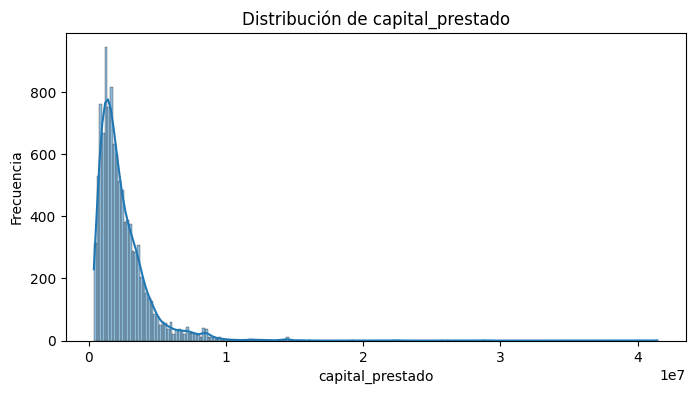

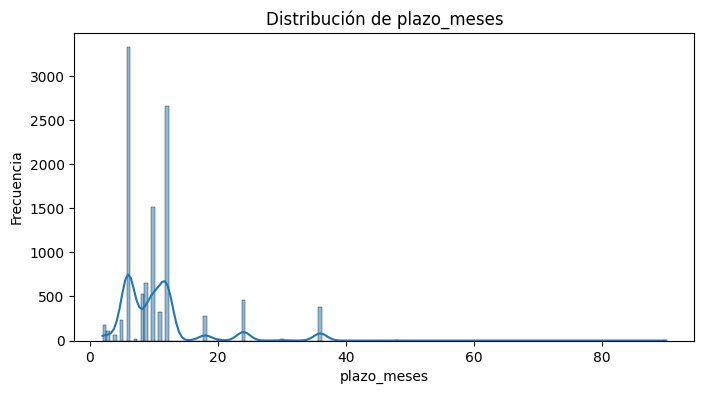

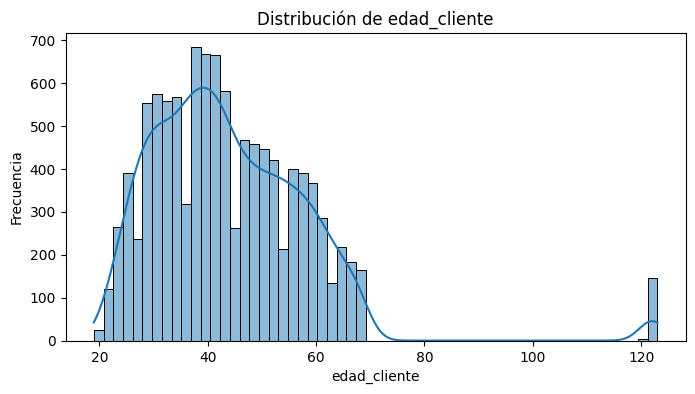

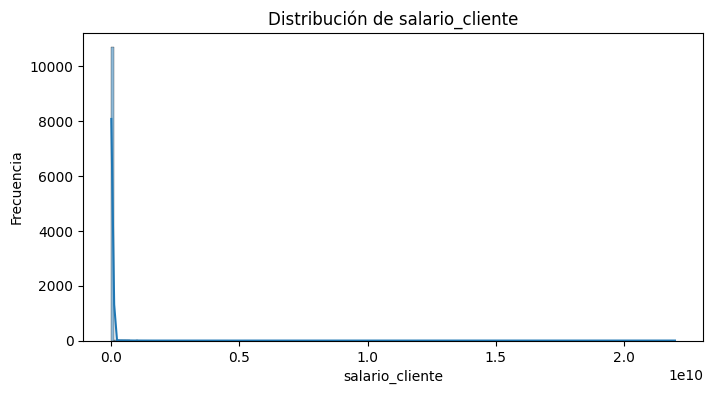

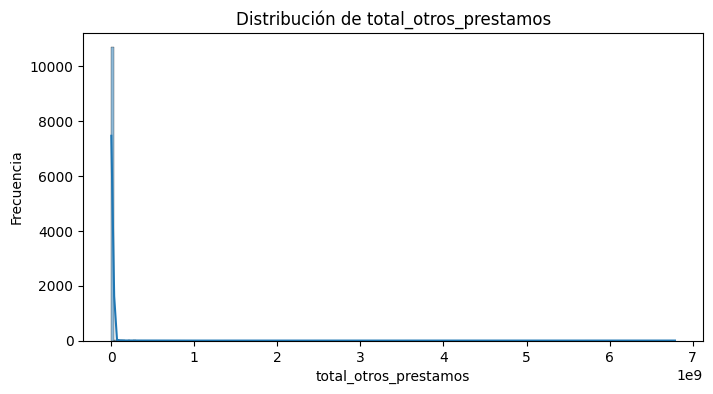

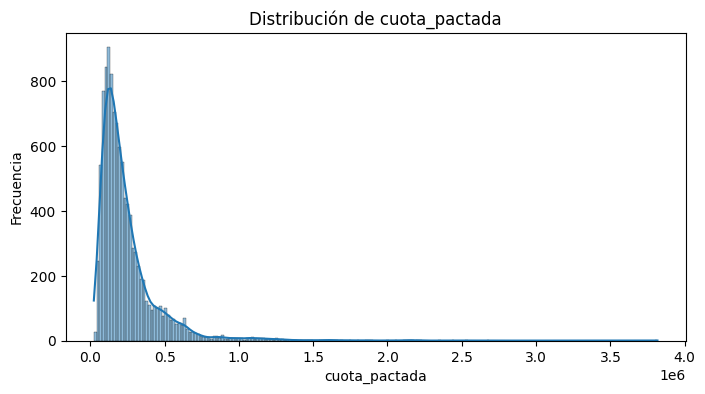

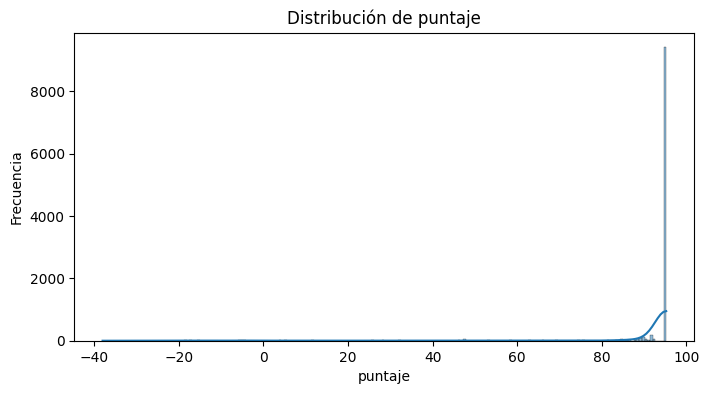

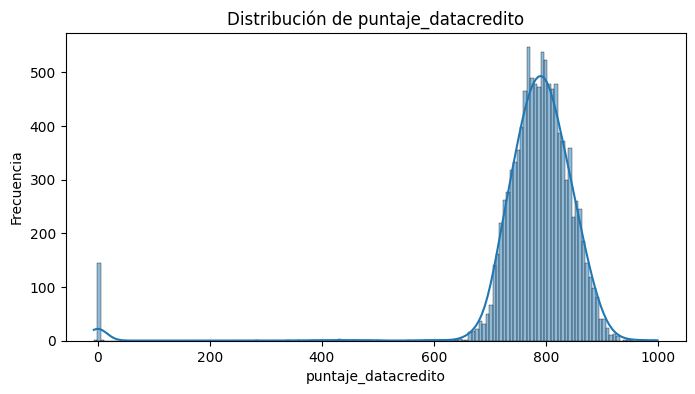

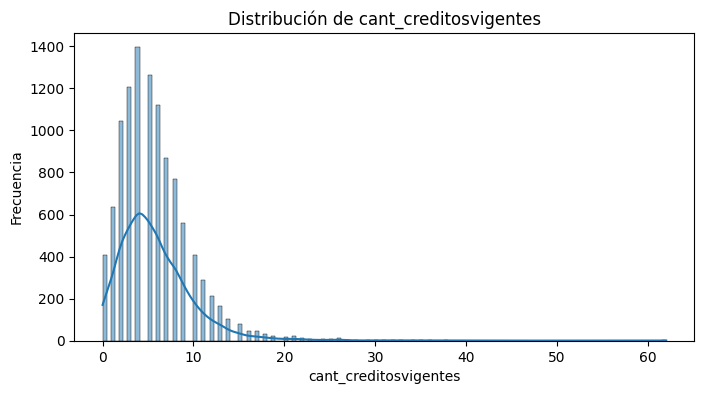

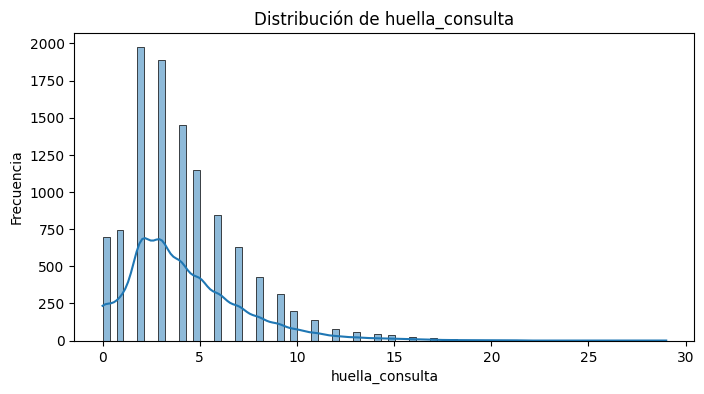

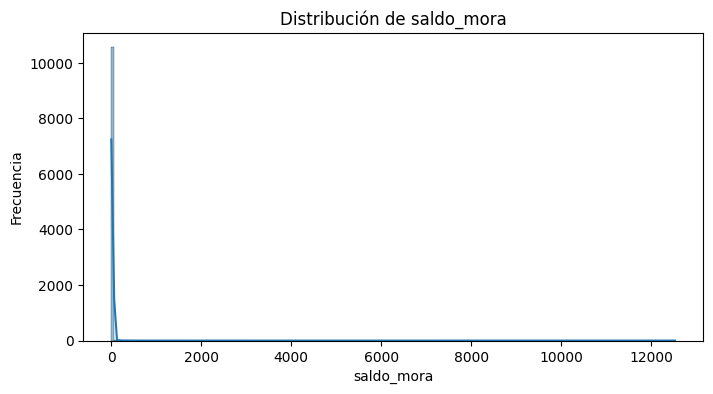

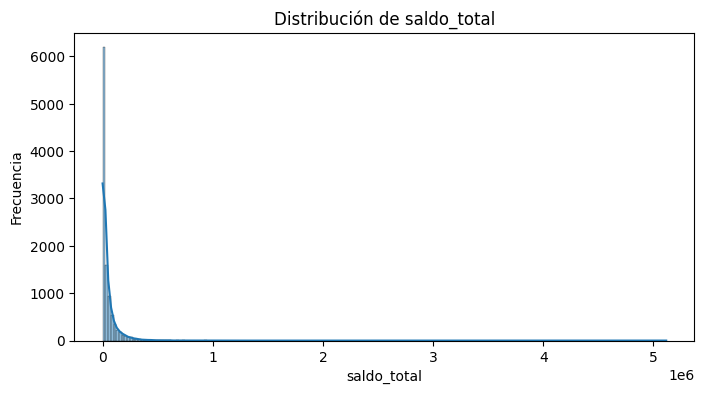

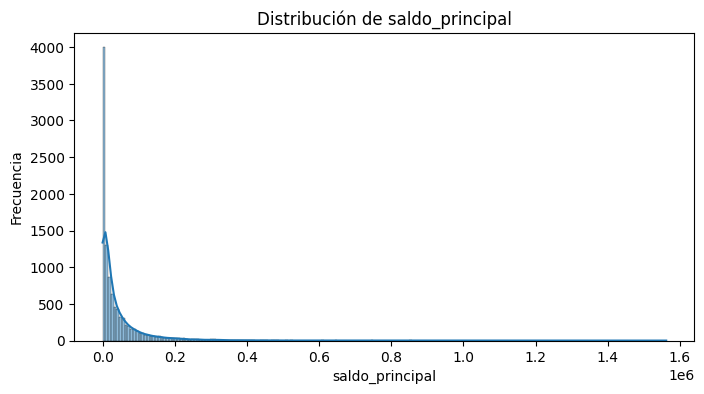

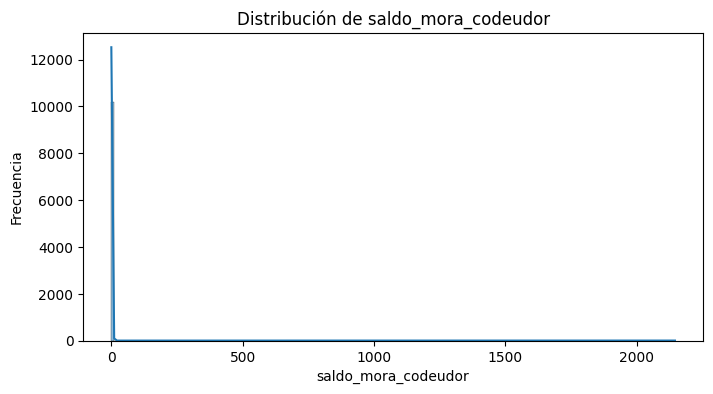

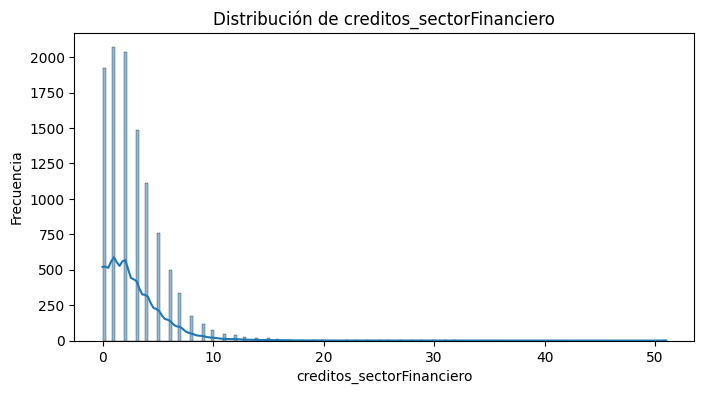

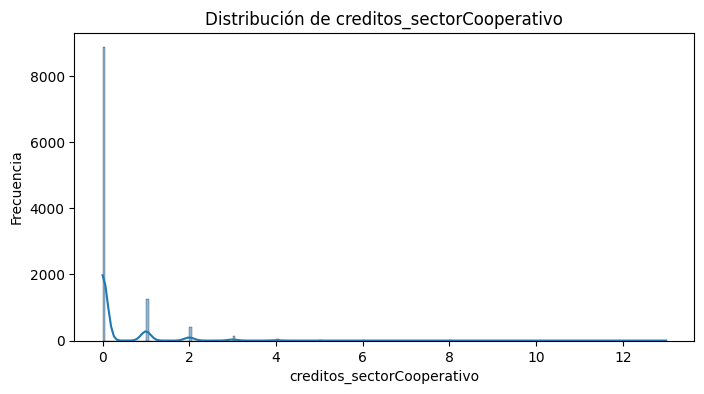

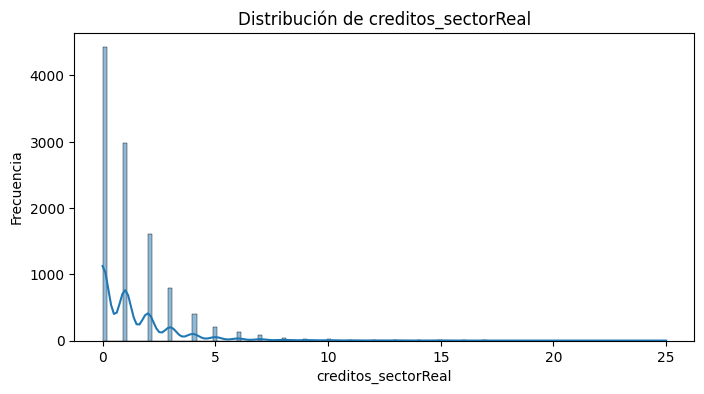

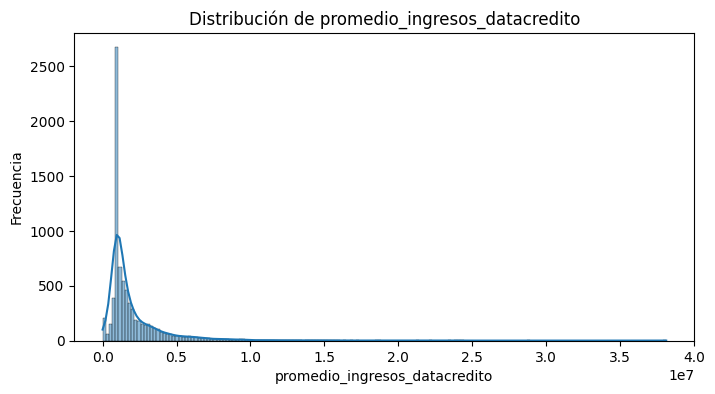

In [92]:
##Histogramas

# Se generan histogramas para las variables numéricas.
# Cada histograma permite observar la distribución individual de una variable.

for col in variables_numericas:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df_limpio, x=col, kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

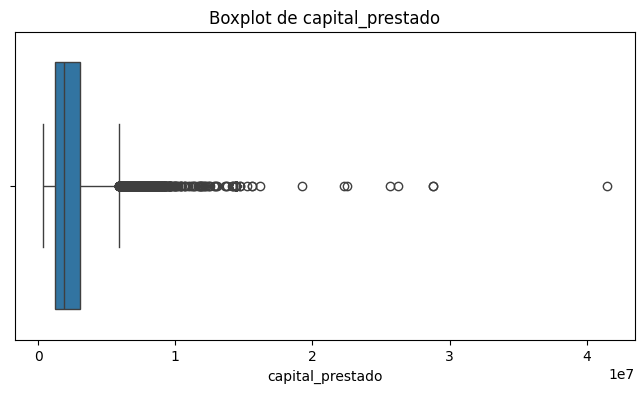

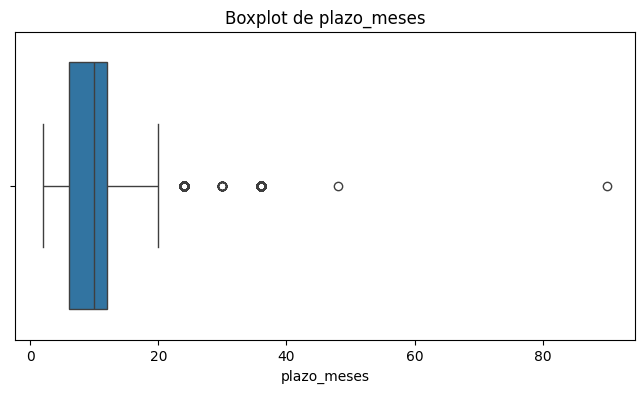

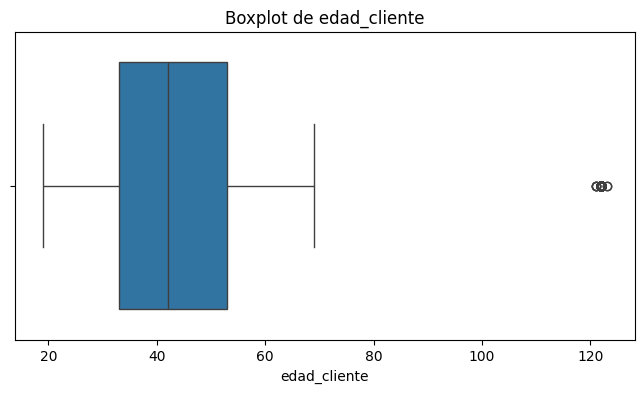

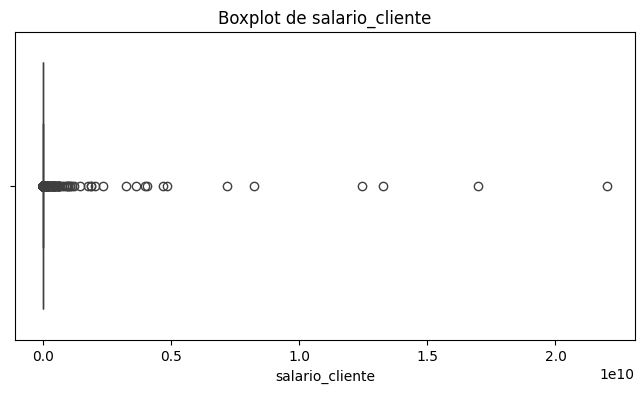

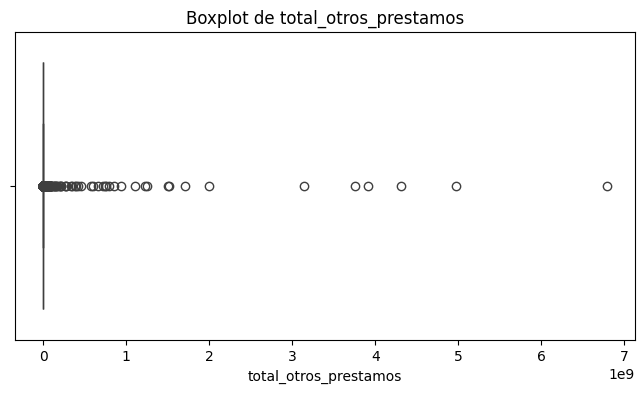

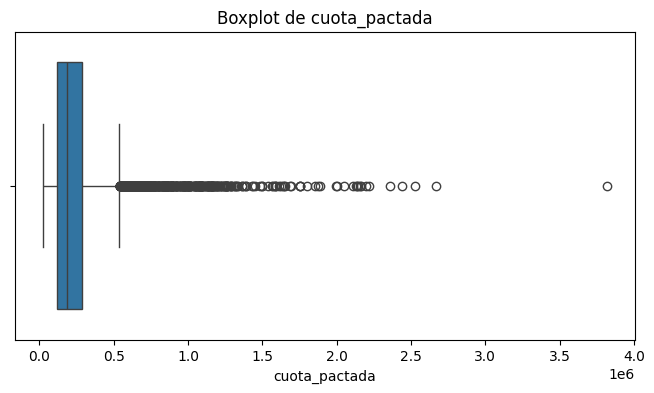

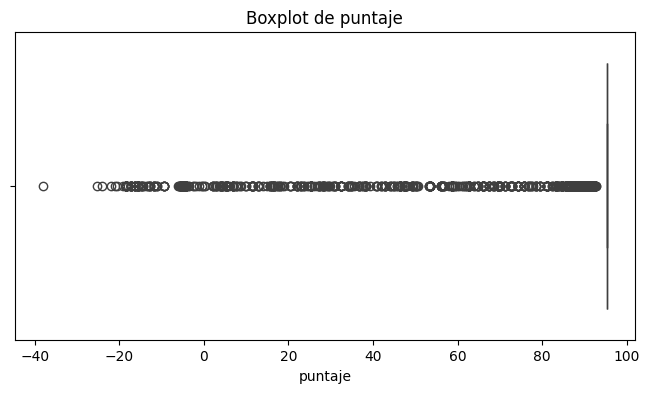

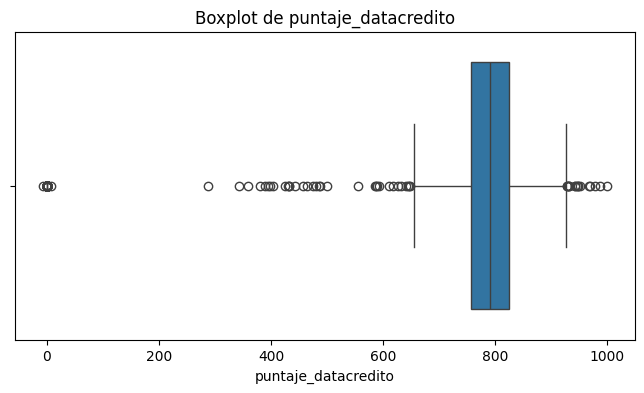

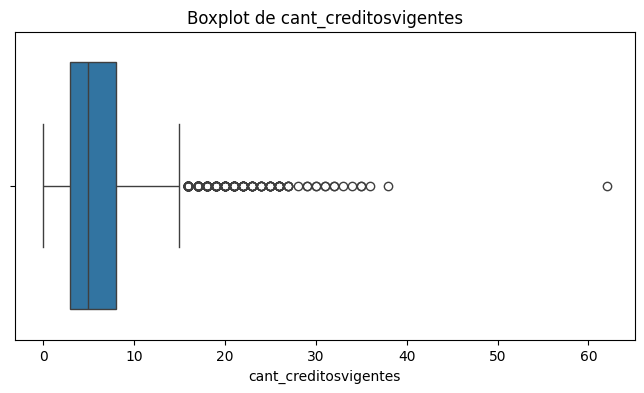

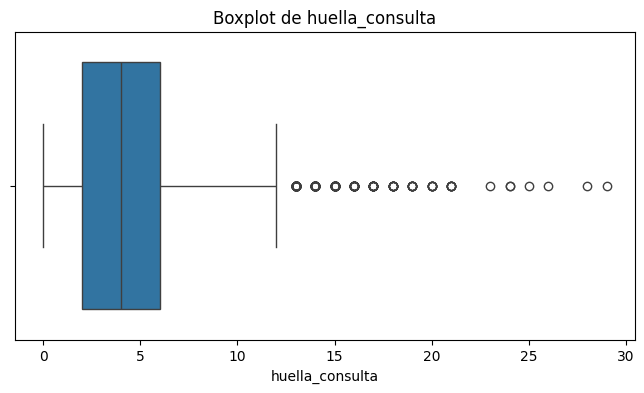

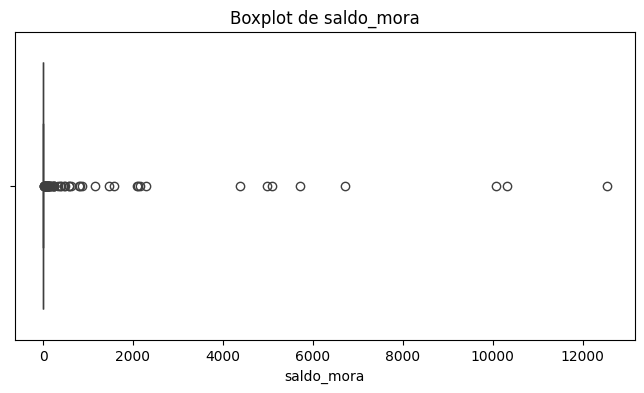

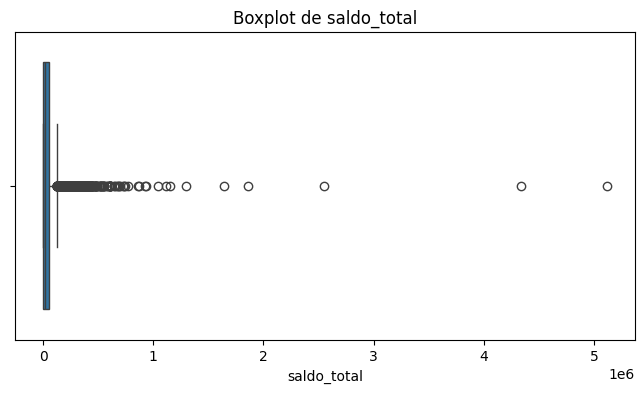

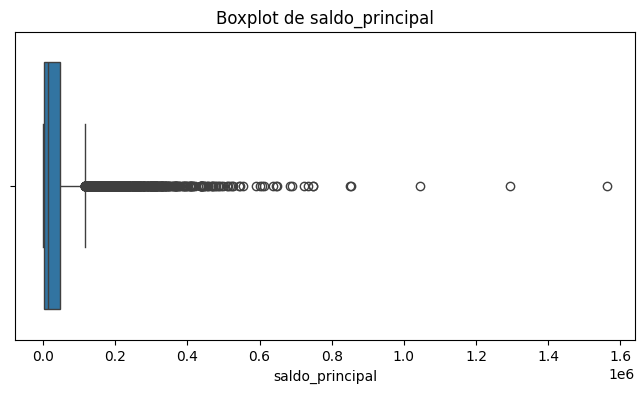

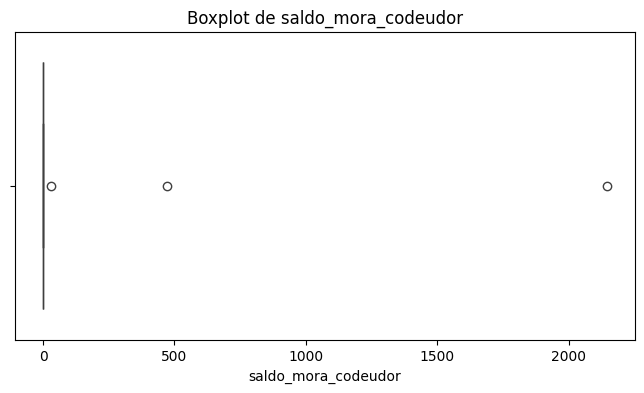

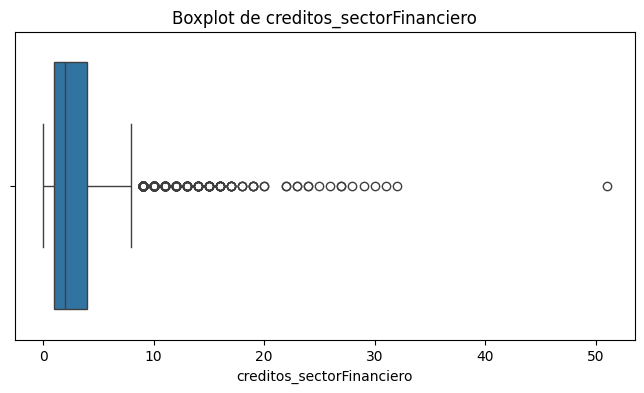

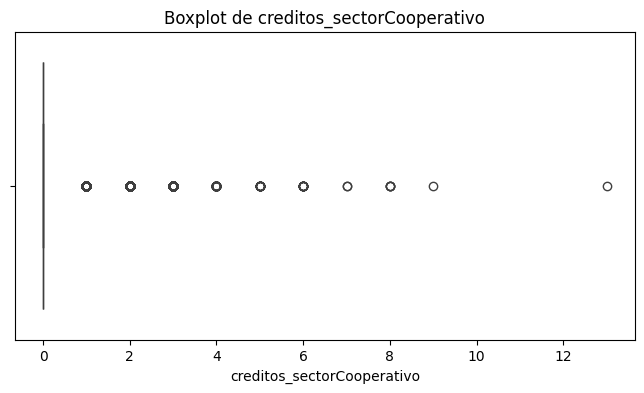

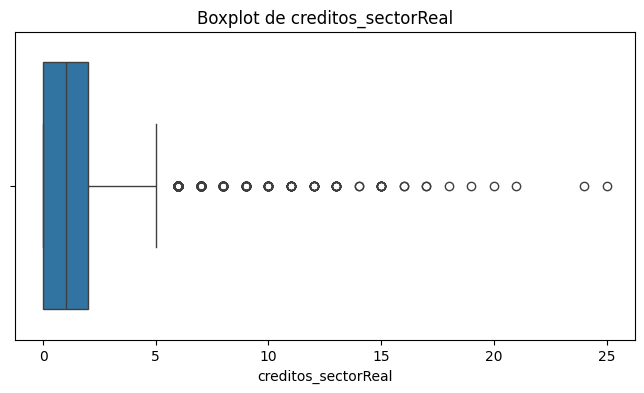

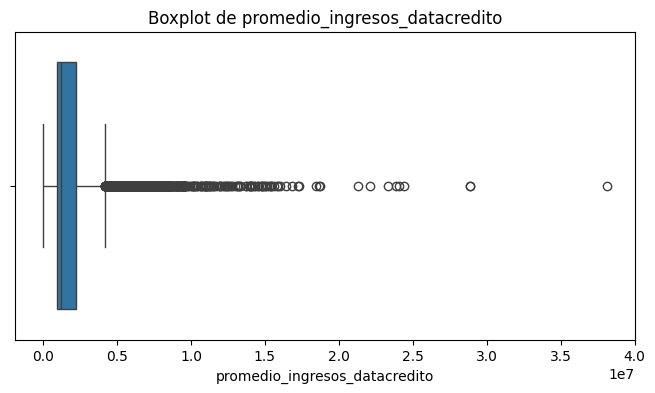

In [93]:
##BOXPLOTS

# Estos gráficos permiten identificar posibles valores extremos,
# asimetrías y diferencias de escala entre las variables.

for col in variables_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_limpio, x=col)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

In [94]:
# Se calcula la cantidad de posibles outliers por variable numérica usando el método IQR.
# El IQR es el rango intercuartílico: Q3 - Q1.
# Se consideran posibles outliers los valores menores al Q1 - 1.5*IQR
# o mayores a Q3 + 1.5*IQR.

resumen_outliers = []

for col in variables_numericas:
    q1 = df_limpio[col].quantile(0.25)
    q3 = df_limpio[col].quantile(0.75)
    iqr = q3 - q1
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    cantidad_outliers = df_limpio[
        (df_limpio[col] < limite_inferior) |
        (df_limpio[col] > limite_superior)
    ][col].count()
    
    porcentaje_outliers = (cantidad_outliers / df_limpio[col].count()) * 100
    
    resumen_outliers.append({
        "variable": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "cantidad_outliers": cantidad_outliers,
        "porcentaje_outliers": porcentaje_outliers
    })

resumen_outliers = pd.DataFrame(resumen_outliers)

resumen_outliers.sort_values(
    by="porcentaje_outliers",
    ascending=False
).round(2)

,variable,q1,q3,iqr,limite_inferior,limite_superior,cantidad_outliers,porcentaje_outliers
15,creditos_sectorCooperativo,0.00,0.00,0.00,0.00,0.00,1895,17.61
6,puntaje,95.23,95.23,0.00,95.23,95.23,1356,12.60
17,promedio_ingresos_datacredito,925157.00,2231859.00,1306702.00,-1034896.00,4191912.00,784,10.01
12,saldo_principal,2690.00,47632.25,44942.25,-64723.38,115045.62,951,9.18
11,saldo_total,2898.00,52982.00,50084.00,-72228.00,128108.00,970,9.14
1,plazo_meses,6.00,12.00,6.00,-3.00,21.00,869,8.07
5,cuota_pactada,121041.50,287833.50,166792.00,-129146.50,538021.50,765,7.11
3,salario_cliente,2000000.00,4875808.00,2875808.00,-2313712.00,9189520.00,718,6.67
4,total_otros_prestamos,500000.00,2000000.00,1500000.00,-1750000.00,4250000.00,589,5.47
0,capital_prestado,1224831.00,3084840.00,1860009.00,-1565182.50,5874853.50,550,5.11


In [95]:
# Se muestra una versión resumida enfocada en la cantidad
# y porcentaje de posibles outliers por variable.

resumen_outliers_simple = resumen_outliers[
    ["variable", "cantidad_outliers", "porcentaje_outliers"]
].sort_values(
    by="porcentaje_outliers",
    ascending=False
)

resumen_outliers_simple.round(2)

,variable,cantidad_outliers,porcentaje_outliers
15,creditos_sectorCooperativo,1895,17.61
6,puntaje,1356,12.60
17,promedio_ingresos_datacredito,784,10.01
12,saldo_principal,951,9.18
11,saldo_total,970,9.14
1,plazo_meses,869,8.07
5,cuota_pactada,765,7.11
3,salario_cliente,718,6.67
4,total_otros_prestamos,589,5.47
0,capital_prestado,550,5.11


In [100]:
## La tabla anterior resume la cantidad y proporción de posibles valores extremos por variable numérica utilizando el método del rango intercuartílico.

## Este método permite identificar observaciones que se alejan considerablemente del comportamiento central de cada variable. Sin embargo, en variables financieras como montos, saldos, ingresos o mora, los valores extremos 
##  no necesariamente representan errores, ya que pueden corresponder a casos reales de clientes con comportamientos atípicos.

## Por este motivo, en esta etapa los outliers no se eliminan automáticamente. Se documentan para ser considerados en etapas posteriores, como ingeniería de características, escalado, transformación logarítmica o tratamiento específico de valores extremos.

In [ ]:
# Se generan tablas de frecuencia para cada variable categórica.
# Para cada columna se muestra la frecuencia absoluta y el porcentaje que representa cada categoría dentro del dataset.

for col in variables_categoricas:
    print(f"Variable categórica: {col}")
    
    tabla_frecuencia = pd.DataFrame({
        "frecuencia": df_limpio[col].value_counts(dropna=False),
        "porcentaje": (df_limpio[col].value_counts(dropna=False, normalize=True) * 100).round(2)
    })
    
    display(tabla_frecuencia)
    print("\n")

Variable categórica: tipo_credito


,frecuencia,porcentaje
tipo_credito,,
4,7747,71.98
9,2876,26.72
10,116,1.08
6,21,0.20
7,2,0.02
68,1,0.01




Variable categórica: tipo_laboral


,frecuencia,porcentaje
tipo_laboral,,
Empleado,6754,62.75
Independiente,4009,37.25




Variable categórica: tendencia_ingresos


,frecuencia,porcentaje
tendencia_ingresos,,
Creciente,5294,49.19
NaN,2990,27.78
Decreciente,1291,11.99
Estable,1188,11.04
-101368,0,0.00
-164315,0,0.00
-224714,0,0.00
-28589,0,0.00
-288,0,0.00




Variable categórica: Pago_atiempo


,frecuencia,porcentaje
Pago_atiempo,,
1,10252,95.25
0,511,4.75


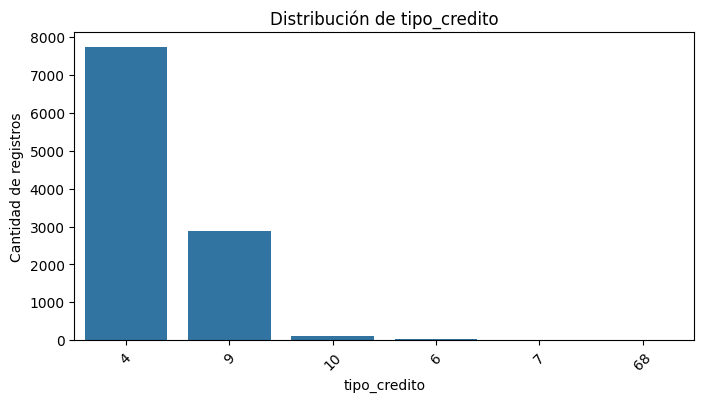

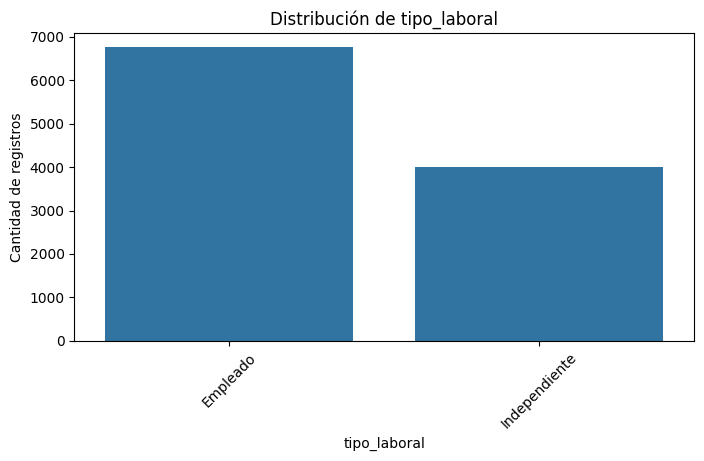

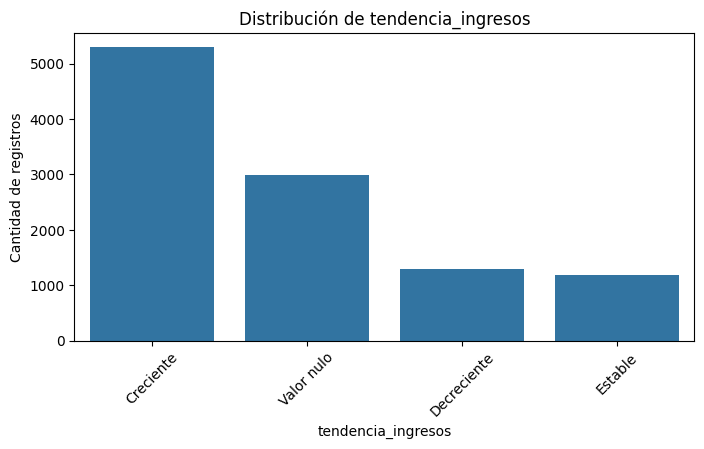

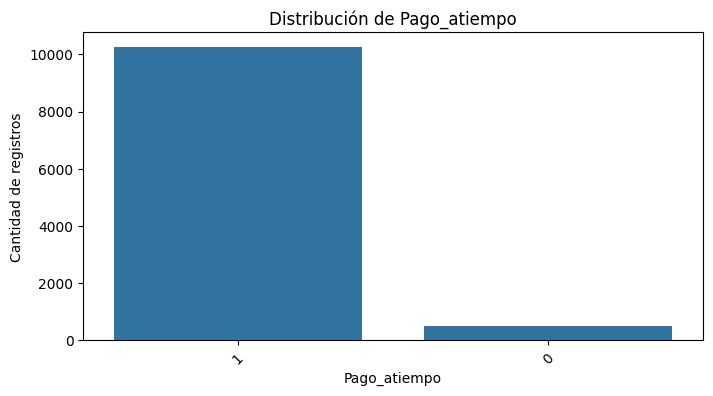

In [ ]:
# Se generan countplots para cada variable categórica.
# Para evitar errores con valores nulos, se crea una serie temporal donde los NaN se representan como "Valor nulo" solo para visualización.


for col in variables_categoricas:
    plt.figure(figsize=(8, 4))
    
    serie_plot = df_limpio[col].astype("object").fillna("Valor nulo").astype(str)
    
    orden_categorias = serie_plot.value_counts().index
    
    sns.countplot(
        x=serie_plot,
        order=orden_categorias
    )
    
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Cantidad de registros")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
### Conclusiones del análisis univariable

# El análisis univariable permitió observar el comportamiento individual de las variables del dataset.

# En las variables numéricas se identifican distribuciones con asimetría y presencia de posibles valores extremos, especialmente en variables financieras como saldos, mora, ingresos y montos asociados al crédito. 
#  Estos valores no se eliminan automáticamente, ya que pueden representar comportamientos reales dentro del contexto financiero.

# En las variables categóricas se observa la distribución de las categorías disponibles y la presencia de clases dominantes. En particular, la variable objetivo `Pago_atiempo` presenta un fuerte desbalance entre sus clases, 
#  lo cual será importante para las etapas posteriores de análisis bivariable, modelado y evaluación.

# Los hallazgos de esta sección sugieren que en etapas posteriores podrían requerirse transformaciones, escalado de variables numéricas, tratamiento de outliers y estrategias específicas para manejar el desbalance de la variable objetivo.

In [110]:
# ================================================
# ANÁLISIS BIVARIABLE
# ================================================

# Se define la variable objetivo del análisis.
# En este proyecto, Pago_atiempo indica si el cliente cumplió o no
# con el pago del crédito en el plazo correspondiente.

objetivo = "Pago_atiempo"

distribucion_objetivo = pd.DataFrame({
    "frecuencia": df_limpio[objetivo].value_counts(dropna=False),
    "porcentaje": (df_limpio[objetivo].value_counts(dropna=False, normalize=True) * 100).round(2)
})

distribucion_objetivo

,frecuencia,porcentaje
Pago_atiempo,,
1,10252,95.25
0,511,4.75


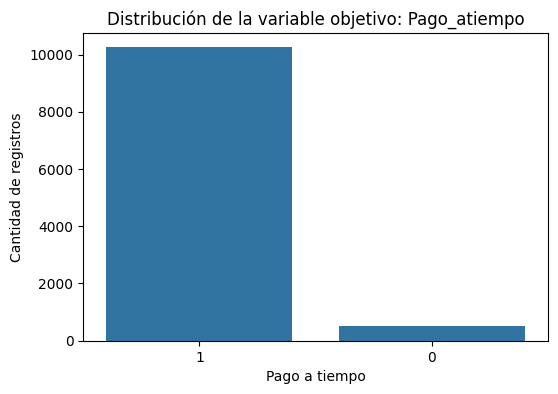

In [113]:
# Se visualiza la distribución de la variable objetivo.
# Para evitar problemas con valores nulos o categorías, se convierte temporalmente a texto.

plt.figure(figsize=(6, 4))

serie_objetivo = df_limpio[objetivo].astype("object").fillna("Valor nulo").astype(str)

sns.countplot(
    x=serie_objetivo,
    order=serie_objetivo.value_counts().index
)

plt.title("Distribución de la variable objetivo: Pago_atiempo")
plt.xlabel("Pago a tiempo")
plt.ylabel("Cantidad de registros")
plt.show()

In [119]:
# Se calculan estadísticas descriptivas de las variables numéricas agrupadas
# por la variable objetivo.
# Esto permite comparar el comportamiento promedio, mediano y la dispersión
# de cada variable según si el cliente pagó o no a tiempo.

resumen_numericas_objetivo = df_limpio.groupby(objetivo, observed=False)[variables_numericas].agg([
    "mean",
    "median",
    "std",
    "min",
    "max"
])

resumen_numericas_objetivo.round(2)

capital_prestado                                               \
                         mean     median         std       min         max   
Pago_atiempo                                                                 
0                  2781774.11  2268000.0  1942337.70  408000.0  11808000.0   
1                  2416996.27  1908446.4  1906438.41  360000.0  41444152.8   

             plazo_meses                       ... creditos_sectorReal         \
                    mean median   std min max  ...                mean median   
Pago_atiempo                                   ...                              
0                  12.45   10.0  9.27   2  36  ...                1.49    1.0   
1                  10.48   10.0  6.46   2  90  ...                1.29    1.0   

                           promedio_ingresos_datacredito             \
               std min max                          mean     median   
Pago_atiempo                                                          
0             2.05   0  15                    1605742.05  1052529.0   
1             1.81   0  25                    2023447.77  1211296.0   

                                               
                     std      min         max  
Pago_atiempo                                   
0             1668892.06  30285.0  18727755.0  
1             2161702.28      0.0  38106581.0  

[2 rows x 90 columns]

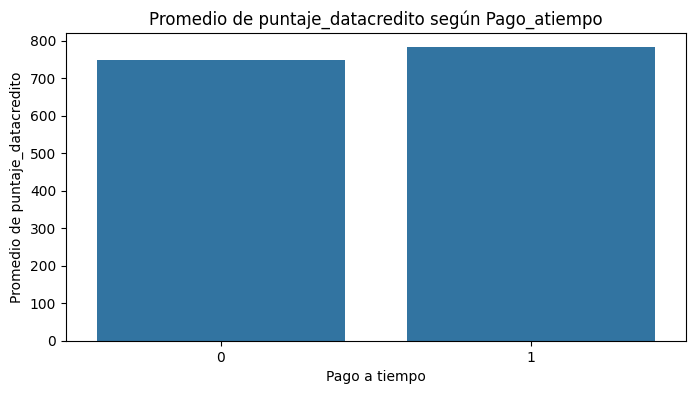

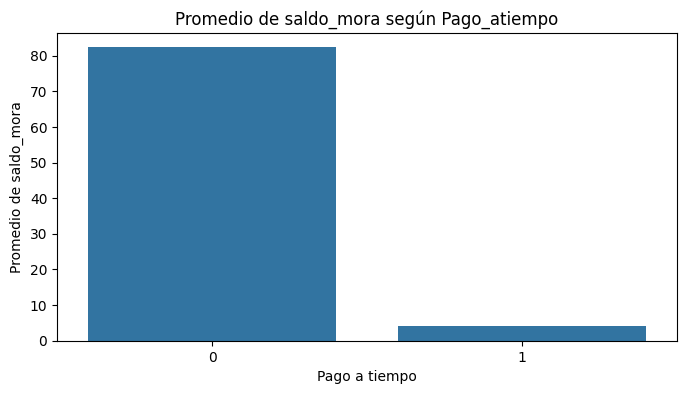

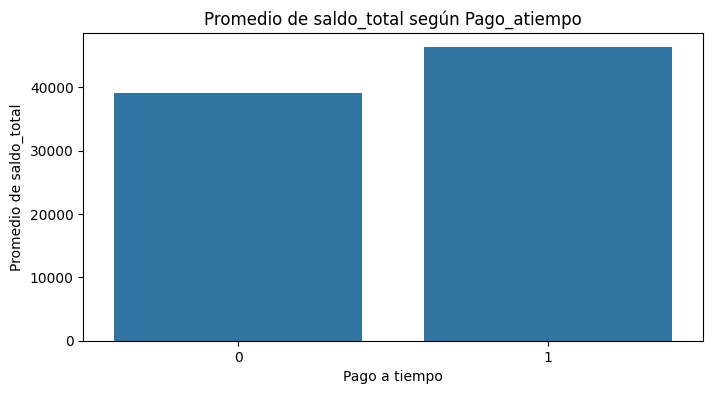

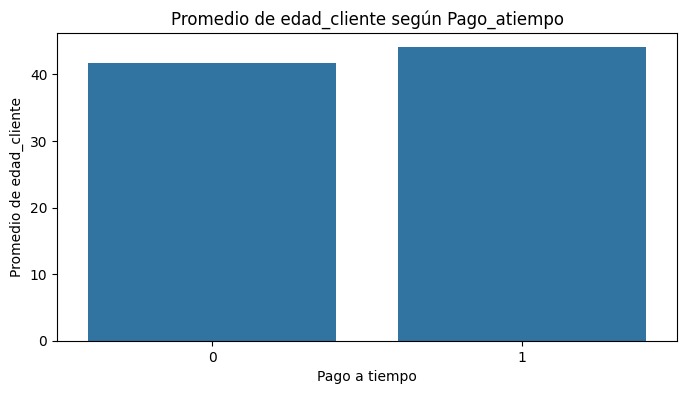

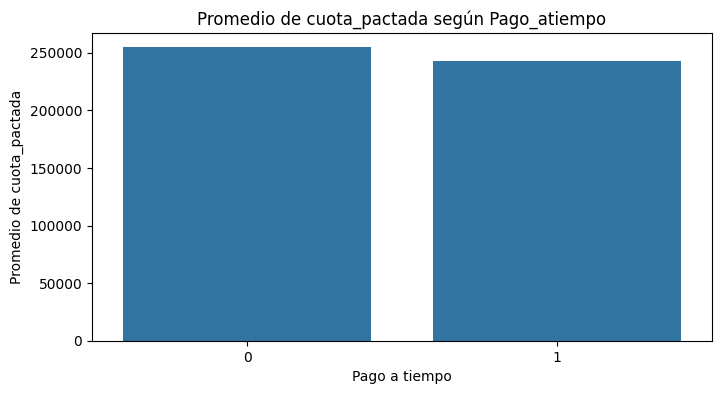

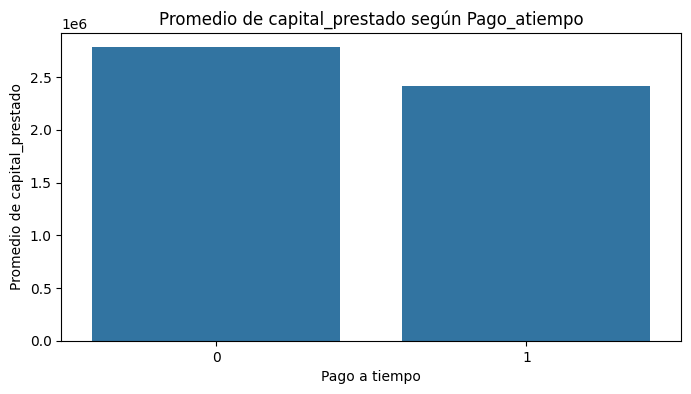

In [120]:
# Se seleccionan variables numéricas relevantes para comparar contra la variable objetivo.
# La selección incluye variables asociadas a puntaje crediticio, mora, saldos, monto prestado y condiciones del crédito.
# 

variables_numericas_relevantes = [
    "puntaje_datacredito",
    "saldo_mora",
    "saldo_total",
    "edad_cliente",
    "cuota_pactada",
    "capital_prestado"
]

# Se comparan los valores promedio de variables numéricas seleccionadas según la variable objetivo.

# Esta visualización permite observar diferencias generales entre grupos de forma más resumida que los boxplots.


for col in variables_numericas_relevantes:
    plt.figure(figsize=(8, 4))
    
    sns.barplot(
        data=df_limpio,
        x=objetivo,
        y=col,
        estimator="mean",
        errorbar=None
    )
    
    plt.title(f"Promedio de {col} según {objetivo}")
    plt.xlabel("Pago a tiempo")
    plt.ylabel(f"Promedio de {col}")
    plt.show()

In [ ]:
#Los gráficos comparativos permiten observar diferencias entre clientes que pagaron a tiempo y clientes que no lo hicieron.

#En particular, variables relacionadas con puntaje crediticio, saldos, mora, monto prestado y cuota pactada pueden mostrar comportamientos distintos entre ambos grupos. 
#  Estas diferencias son relevantes porque podrían aportar señales útiles para anticipar el riesgo de incumplimiento.

#En esta etapa los gráficos se utilizan como análisis exploratorio, por lo que las diferencias observadas no implican causalidad directa. 
#  Sin embargo, ayudan a identificar variables candidatas para ingeniería de características y modelado predictivo.

In [123]:
# ================================================
# ANÁLISIS MULTIVARIABLE
# ================================================

# Se calcula la matriz de correlación entre variables numéricas.
# Esto permite identificar relaciones lineales entre pares de variables.

# Valores cercanos a 1 indican correlación positiva fuerte,
# valores cercanos a -1 indican correlación negativa fuerte,
# y valores cercanos a 0 indican baja relación lineal.

matriz_correlacion = df_limpio[variables_numericas].corr()

matriz_correlacion.round(2)

,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito
capital_prestado,1.00,0.30,0.13,0.05,0.07,0.76,-0.04,-0.15,0.05,0.03,0.03,0.14,0.18,-0.01,0.11,-0.02,-0.08,0.12
plazo_meses,0.30,1.00,-0.09,-0.01,-0.01,-0.23,-0.07,0.00,-0.00,0.05,0.02,-0.03,-0.05,-0.00,-0.00,0.03,-0.00,0.02
edad_cliente,0.13,-0.09,1.00,0.15,0.20,0.15,0.03,-0.38,-0.04,-0.24,0.03,0.05,0.08,0.02,0.01,-0.00,-0.05,0.03
salario_cliente,0.05,-0.01,0.15,1.00,0.60,0.05,-0.00,-0.19,-0.04,-0.04,0.00,0.00,0.01,-0.00,-0.02,-0.01,-0.03,-0.00
total_otros_prestamos,0.07,-0.01,0.20,0.60,1.00,0.06,-0.01,-0.28,-0.05,-0.05,0.01,0.08,0.11,-0.00,-0.03,-0.01,-0.03,0.02
cuota_pactada,0.76,-0.23,0.15,0.05,0.06,1.00,-0.01,-0.13,0.05,0.00,0.00,0.15,0.20,-0.01,0.11,-0.03,-0.07,0.09
puntaje,-0.04,-0.07,0.03,-0.00,-0.01,-0.01,1.00,0.09,0.01,-0.08,-0.10,0.01,0.01,0.00,0.03,0.03,-0.02,0.05
puntaje_datacredito,-0.15,0.00,-0.38,-0.19,-0.28,-0.13,0.09,1.00,0.11,0.02,-0.19,0.07,0.08,0.00,0.15,0.03,-0.05,0.12
cant_creditosvigentes,0.05,-0.00,-0.04,-0.04,-0.05,0.05,0.01,0.11,1.00,0.32,0.01,0.40,0.49,-0.01,0.79,0.20,0.54,0.16
huella_consulta,0.03,0.05,-0.24,-0.04,-0.05,0.00,-0.08,0.02,0.32,1.00,-0.01,0.14,0.17,-0.02,0.25,0.02,0.17,0.02


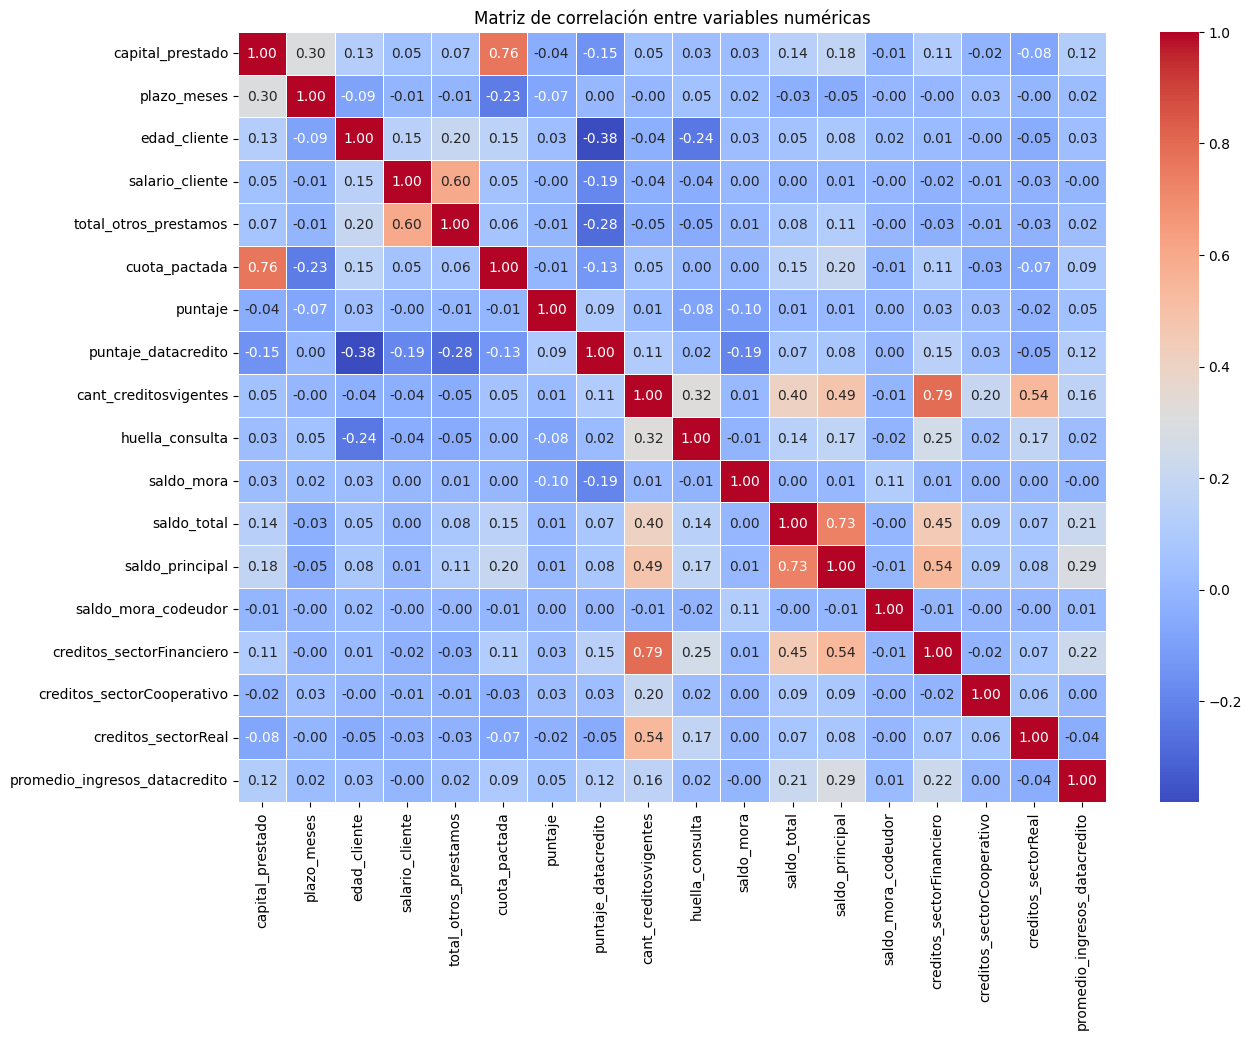

In [124]:
# Se visualiza la matriz de correlación mediante un heatmap.
# Este gráfico facilita la detección de relaciones fuertes entre variables numéricas.

plt.figure(figsize=(14, 10))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables numéricas")
plt.show()

### Correlaciones más relevantes entre variables numéricas

Luego de visualizar la matriz de correlación, se construye una tabla con las relaciones lineales más fuertes entre variables numéricas.

Esta tabla permite identificar pares de variables que podrían estar estrechamente relacionadas, posibles redundancias o relaciones esperables dentro del contexto financiero del dataset.

In [125]:
# Se extraen las correlaciones entre variables numéricas.
# Para evitar duplicados, se toma únicamente la mitad superior de la matriz.
# Luego se ordenan las correlaciones según su valor absoluto.

correlaciones = matriz_correlacion.where(
    np.triu(np.ones(matriz_correlacion.shape), k=1).astype(bool)
)

correlaciones_fuertes = correlaciones.stack().reset_index()
correlaciones_fuertes.columns = ["variable_1", "variable_2", "correlacion"]

correlaciones_fuertes["correlacion_absoluta"] = correlaciones_fuertes["correlacion"].abs()

correlaciones_fuertes = correlaciones_fuertes.sort_values(
    by="correlacion_absoluta",
    ascending=False
)

correlaciones_fuertes.head(15).round(3)

,variable_1,variable_2,correlacion,correlacion_absoluta
158,cant_creditosvigentes,creditos_sectorFinanciero,0.791,0.791
5,capital_prestado,cuota_pactada,0.764,0.764
210,saldo_total,saldo_principal,0.735,0.735
58,salario_cliente,total_otros_prestamos,0.597,0.597
160,cant_creditosvigentes,creditos_sectorReal,0.541,0.541
230,saldo_principal,creditos_sectorFinanciero,0.537,0.537
156,cant_creditosvigentes,saldo_principal,0.486,0.486
212,saldo_total,creditos_sectorFinanciero,0.452,0.452
155,cant_creditosvigentes,saldo_total,0.402,0.402
43,edad_cliente,puntaje_datacredito,-0.381,0.381


In [126]:
# Se filtran correlaciones fuertes usando un umbral.
# En este caso se consideran relaciones fuertes aquellas con valor absoluto mayor o igual a 0.70.

umbral_correlacion = 0.70

correlaciones_altas = correlaciones_fuertes[
    correlaciones_fuertes["correlacion_absoluta"] >= umbral_correlacion
]

correlaciones_altas.round(3)

,variable_1,variable_2,correlacion,correlacion_absoluta
158,cant_creditosvigentes,creditos_sectorFinanciero,0.791,0.791
5,capital_prestado,cuota_pactada,0.764,0.764
210,saldo_total,saldo_principal,0.735,0.735


#================================================================================================================================================================================
### Se filtran correlaciones fuertes usando un umbral.
##### En este caso se consideran relaciones fuertes aquellas con valor absoluto mayor o igual a 0.70.
##### Estas relaciones pueden ser útiles para detectar variables con comportamiento similar, posibles redundancias o dependencias relevantes entre atributos financieros.
#================================================================================================================================================================================

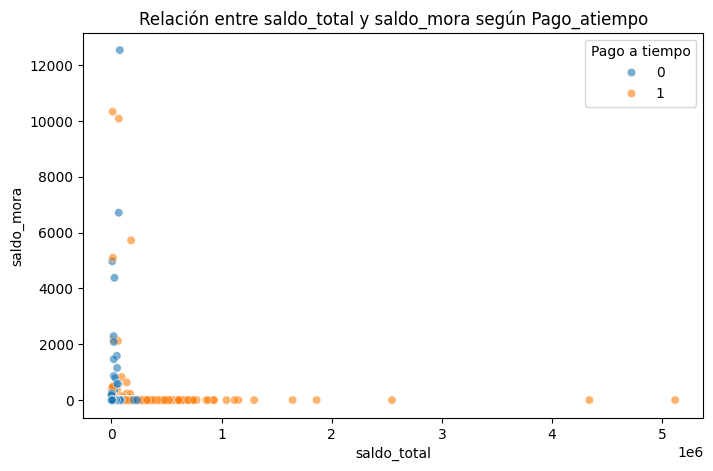

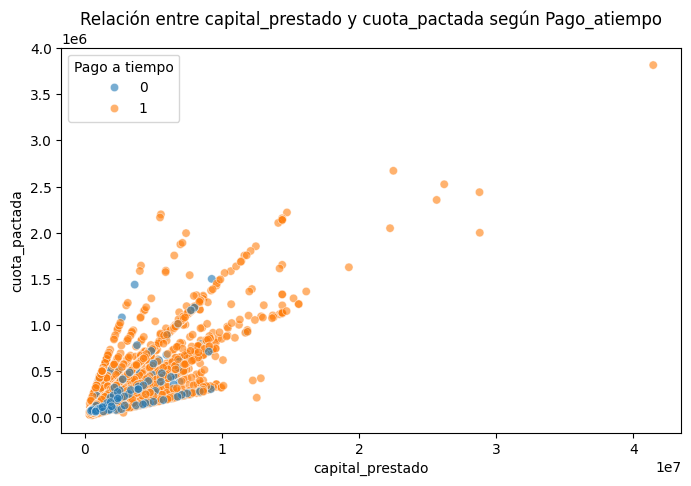

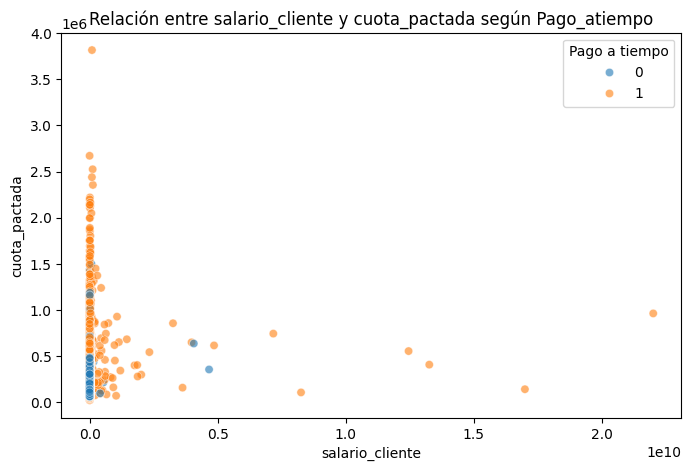

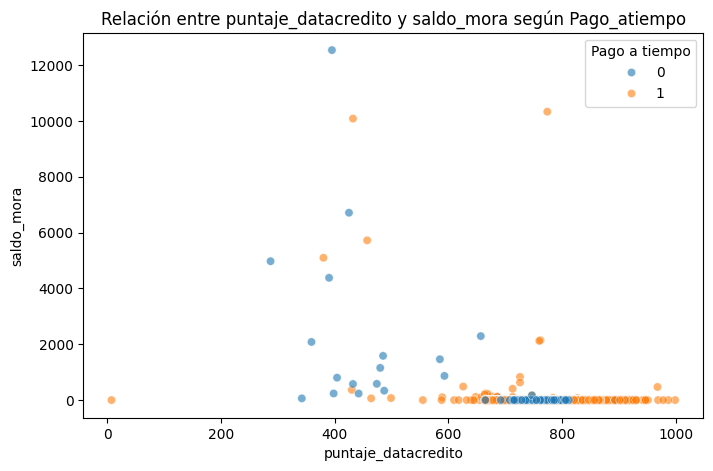

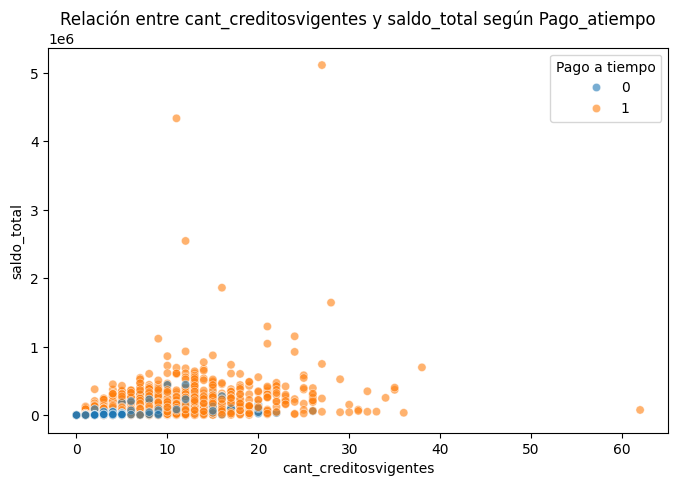

In [133]:
# Gráficos de dispersión entre variables numéricas

# Se seleccionan pares de variables numéricas con sentido financiero.
# Estos pares permiten analizar relaciones entre saldos, mora, cuota, capital,
# ingresos y comportamiento crediticio.

pares_dispersion = [
    ("saldo_total", "saldo_mora"),
    ("capital_prestado", "cuota_pactada"),
    ("salario_cliente", "cuota_pactada"),
    ("puntaje_datacredito", "saldo_mora"),
    ("cant_creditosvigentes", "saldo_total")
]

# Se generan gráficos de dispersión utilizando Pago_atiempo como hue.
# Esto permite observar si las clases de la variable objetivo presentan
# comportamientos diferenciados dentro de las relaciones entre variables.

for x_var, y_var in pares_dispersion:
    plt.figure(figsize=(8, 5))
    
    sns.scatterplot(
        data=df_limpio,
        x=x_var,
        y=y_var,
        hue=objetivo,
        alpha=0.6
    )
    
    plt.title(f"Relación entre {x_var} y {y_var} según {objetivo}")
    plt.xlabel(x_var)
    plt.ylabel(y_var)
    plt.legend(title="Pago a tiempo")
    plt.show()


Los gráficos de dispersión permiten observar relaciones entre variables numéricas relevantes del contexto financiero.

La relación entre `capital_prestado` y `cuota_pactada` puede indicar coherencia entre el monto otorgado y el valor de la cuota. Por otro lado, variables como `saldo_mora`, `saldo_total` y `puntaje_datacredito` permiten explorar señales asociadas al comportamiento crediticio del cliente.

En algunos casos, la presencia de valores extremos puede dificultar la separación visual entre clientes que pagan y no pagan a tiempo. Sin embargo, estos gráficos ayudan a identificar relaciones generales, posibles patrones de riesgo y variables que podrían ser útiles para la etapa de ingeniería de características.

*Se intento hacer una version con porcentajes para intentar aumentar la legibilidad de los graficos por medio de descartar valores que rompian la escala promedio pero dichos graficos presentaban muchos inconvenientes a la hora de interpretarlos, asi que fueron descartados.

### Tablas cruzadas entre variables categóricas y Pago_atiempo

Se analizan las variables categóricas respecto a la variable objetivo mediante tablas cruzadas.

Estas tablas permiten observar cómo se distribuye el pago a tiempo dentro de cada categoría y ayudan a identificar posibles diferencias de comportamiento entre grupos.

Variable categórica: tipo_credito
Variable categórica: tipo_laboral
Variable categórica: tendencia_ingresos


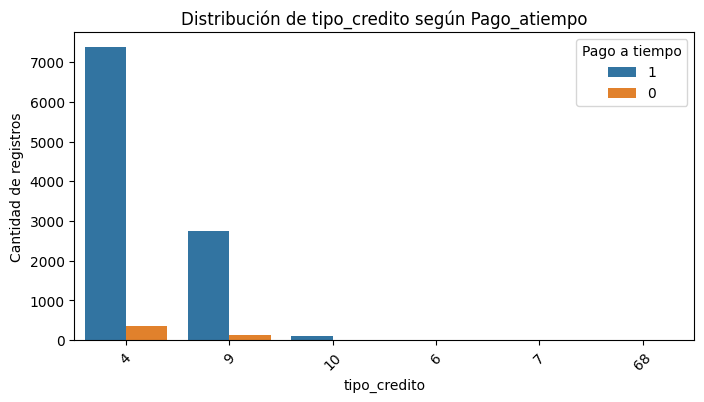

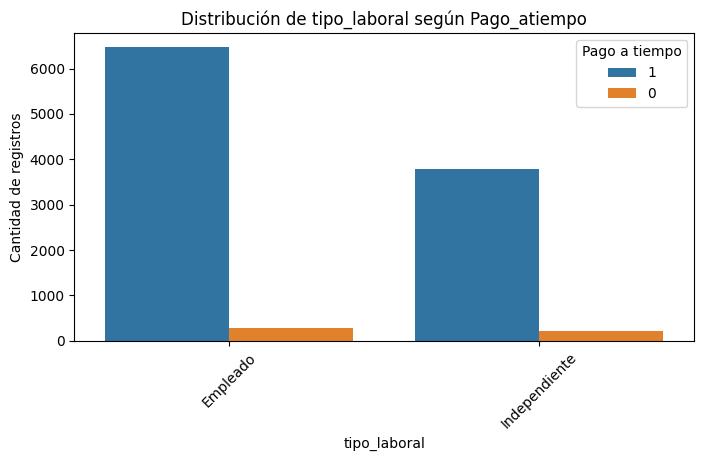

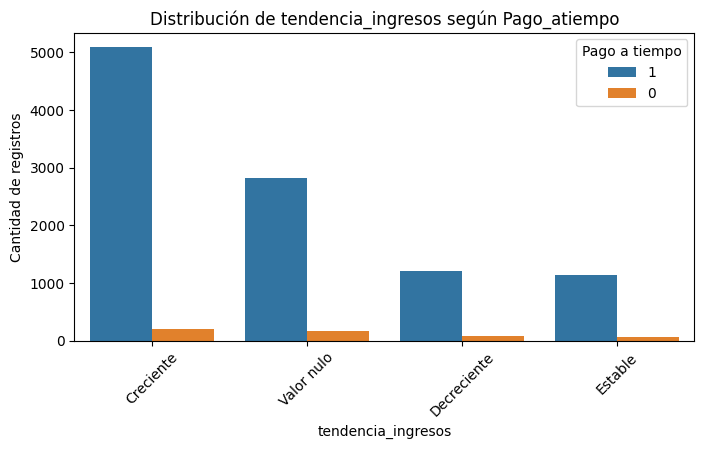

In [137]:
# Se generan tablas cruzadas para analizar la relación entre variables categóricas
# y la variable objetivo Pago_atiempo.
# Se calcula tanto la frecuencia absoluta como la proporción por categoría.

variables_categoricas_explicativas = [
    col for col in variables_categoricas
    if col != objetivo
]

for col in variables_categoricas_explicativas:
    print(f"Variable categórica: {col}")
    
    tabla_absoluta = pd.crosstab(
        df_limpio[col],
        df_limpio[objetivo],
        dropna=False
    )
    
    tabla_porcentual = pd.crosstab(
        df_limpio[col],
        df_limpio[objetivo],
        normalize="index",
        dropna=False
    ) * 100
    

# Se generan gráficos de conteo para variables categóricas usando Pago_atiempo como hue.
# Esto permite visualizar cómo se distribuye la variable objetivo dentro de cada categoría.

for col in variables_categoricas_explicativas:
    df_plot = df_limpio[[col, objetivo]].copy()
    
    df_plot[col] = df_plot[col].astype("object").fillna("Valor nulo").astype(str)
    df_plot[objetivo] = df_plot[objetivo].astype("object").fillna("Valor nulo").astype(str)
    
    plt.figure(figsize=(8, 4))
    
    sns.countplot(
        data=df_plot,
        x=col,
        hue=objetivo,
        order=df_plot[col].value_counts().index
    )
    
    plt.title(f"Distribución de {col} según {objetivo}")
    plt.xlabel(col)
    plt.ylabel("Cantidad de registros")
    plt.xticks(rotation=45)
    plt.legend(title="Pago a tiempo")
    plt.show()

A partir de los gráficos categóricos respecto a `Pago_atiempo`, se observa que la clase mayoritaria corresponde a clientes que pagaron a tiempo. Este patrón se repite en todas las variables categóricas analizadas, lo que confirma nuevamente el desbalance de la variable objetivo.

En `tipo_credito`, la mayor concentración de registros se encuentra en las categorías `4` y `9`. Dentro de ambas categorías predominan ampliamente los clientes que pagaron a tiempo. Las demás categorías presentan muy baja frecuencia, por lo que su interpretación debe hacerse con cautela, ya que cuentan con pocos registros para extraer conclusiones sólidas.

En `tipo_laboral`, tanto los clientes `Empleado` como `Independiente` muestran predominio de pagos a tiempo. Sin embargo, la categoría `Empleado` concentra una mayor cantidad total de registros. Esto puede indicar que el dataset tiene mayor representación de clientes con relación laboral dependiente, lo cual podría influir en el comportamiento general del modelo si no se evalúa correctamente.

En `tendencia_ingresos`, la categoría `Creciente` es la más frecuente, seguida por los registros con valor nulo. También aparecen las categorías `Decreciente` y `Estable`, aunque con menor cantidad de observaciones. En todas las categorías vuelve a predominar el pago a tiempo, pero la presencia importante de valores nulos en esta variable sugiere que deberá evaluarse su tratamiento en etapas posteriores.

En general, estas variables categóricas pueden aportar información útil para segmentar clientes, pero deben analizarse considerando el fuerte desbalance de `Pago_atiempo`. Por este motivo, las frecuencias absolutas pueden ser engañosas y conviene complementar el análisis con porcentajes por categoría.

### Interpretación general del análisis multivariable

El análisis multivariable permitió observar relaciones entre variables financieras, crediticias y categóricas del dataset.

A partir de la matriz de correlación y los gráficos de dispersión, se identifican relaciones esperables entre variables asociadas a montos, saldos, mora, cuotas y comportamiento crediticio. Algunas variables presentan asociaciones fuertes, lo que puede indicar redundancia parcial o relaciones naturales del negocio.

Los gráficos de dispersión muestran que los valores extremos tienen un impacto importante en la visualización, especialmente en variables financieras. Por este motivo, se utilizó un recorte visual por percentil para analizar la concentración principal de datos sin modificar el dataset original.

En las variables categóricas, se observa que el pago a tiempo predomina en todas las categorías, aunque esto debe interpretarse considerando el fuerte desbalance de la variable objetivo `Pago_atiempo`.

En conjunto, estos hallazgos sugieren que variables relacionadas con mora, saldos, puntajes, tipo de crédito, tipo laboral e ingresos podrían aportar señales relevantes para el análisis de riesgo crediticio.

In [138]:
# ================================================
# REGLAS DE VALIDACIÓN DE DATOS
# ================================================

# Se proponen reglas de validación a partir de los hallazgos del EDA.
# Estas reglas podrían utilizarse en etapas posteriores del pipeline
# para controlar la calidad de datos antes del entrenamiento o predicción.

reglas_validacion = pd.DataFrame({
    "variable": [
        "capital_prestado",
        "cuota_pactada",
        "edad_cliente",
        "salario_cliente",
        "saldo_mora",
        "saldo_total",
        "saldo_principal",
        "puntaje_datacredito",
        "Pago_atiempo",
        "tipo_credito",
        "tipo_laboral",
        "tendencia_ingresos"
    ],
    "regla": [
        "Debe ser mayor a 0",
        "Debe ser mayor o igual a 0",
        "Debe estar dentro de un rango válido para clientes financieros",
        "Debe ser mayor o igual a 0",
        "Debe ser mayor o igual a 0",
        "Debe ser mayor o igual a 0",
        "Debe ser mayor o igual a 0",
        "Debe estar dentro del rango esperado de puntaje crediticio",
        "Debe contener únicamente las clases esperadas",
        "Debe pertenecer a las categorías conocidas de tipo de crédito",
        "Debe pertenecer a las categorías conocidas de tipo laboral",
        "Debe contener solo categorías válidas o valor nulo"
    ],
    "justificacion": [
        "Un crédito no debería tener capital prestado nulo o negativo.",
        "La cuota pactada representa un valor de pago y no debería ser negativa.",
        "Edades fuera de rango podrían indicar errores de carga.",
        "El salario no debería presentar valores negativos.",
        "La mora representa deuda vencida y no debería ser negativa.",
        "El saldo total no debería ser negativo.",
        "El saldo principal no debería ser negativo.",
        "Puntajes fuera de rango podrían indicar datos inválidos.",
        "La variable objetivo debe mantener consistencia para modelado.",
        "Categorías desconocidas podrían indicar errores de carga.",
        "Categorías desconocidas podrían afectar la interpretación.",
        "Se detectaron valores inconsistentes previamente en esta variable."
    ]
})

reglas_validacion

,variable,regla,justificacion
0,capital_prestado,Debe ser mayor a 0,Un crédito no debería tener capital prestado n...
1,cuota_pactada,Debe ser mayor o igual a 0,La cuota pactada representa un valor de pago y...
2,edad_cliente,Debe estar dentro de un rango válido para clie...,Edades fuera de rango podrían indicar errores ...
3,salario_cliente,Debe ser mayor o igual a 0,El salario no debería presentar valores negati...
4,saldo_mora,Debe ser mayor o igual a 0,La mora representa deuda vencida y no debería ...
5,saldo_total,Debe ser mayor o igual a 0,El saldo total no debería ser negativo.
6,saldo_principal,Debe ser mayor o igual a 0,El saldo principal no debería ser negativo.
7,puntaje_datacredito,Debe estar dentro del rango esperado de puntaj...,Puntajes fuera de rango podrían indicar datos ...
8,Pago_atiempo,Debe contener únicamente las clases esperadas,La variable objetivo debe mantener consistenci...
9,tipo_credito,Debe pertenecer a las categorías conocidas de ...,Categorías desconocidas podrían indicar errore...


### Transformaciones candidatas

A partir del análisis exploratorio, se identifican transformaciones que podrían aplicarse en etapas posteriores del pipeline:

- Imputación de valores nulos en variables como `tendencia_ingresos`, `promedio_ingresos_datacredito`, `saldo_mora_codeudor`, `saldo_principal`, `saldo_mora`, `saldo_total` y `puntaje_datacredito`.
- Codificación de variables categóricas como `tipo_credito`, `tipo_laboral` y `tendencia_ingresos`.
- Escalado de variables numéricas, debido a que existen magnitudes muy diferentes entre saldos, ingresos, cuotas, puntajes y conteos.
- Evaluación de transformaciones logarítmicas en variables financieras con alta asimetría.
- Tratamiento controlado de outliers, especialmente en variables de montos, saldos, mora e ingresos.
- Evaluación de balanceo de clases para la variable objetivo `Pago_atiempo`, dado su fuerte desbalance.

### Atributos derivados posibles

A partir de las variables disponibles, podrían construirse atributos derivados que aporten información adicional al modelo:

- `ratio_cuota_salario`: relación entre la cuota pactada y el salario del cliente.
- `ratio_mora_saldo_total`: proporción del saldo total que corresponde a mora.
- `ratio_capital_salario`: relación entre el capital prestado y el salario del cliente.
- `flag_tiene_mora`: indicador binario para identificar clientes con saldo en mora.
- `total_creditos_sectoriales`: suma de créditos en sector financiero, cooperativo y real.
- `antiguedad_prestamo`: diferencia entre la fecha actual o fecha de corte y `fecha_prestamo`.
- `nivel_riesgo_puntaje`: segmentación del puntaje crediticio en rangos de riesgo.
- `carga_crediticia_total`: combinación entre créditos vigentes, otros préstamos y cuota pactada.

Estos atributos podrían ayudar a representar mejor la capacidad de pago, exposición crediticia y comportamiento financiero del cliente.

## Conclusiones generales del EDA

El análisis exploratorio permitió comprender la estructura general del dataset, caracterizar las variables disponibles, revisar valores nulos, corregir tipos de datos y detectar inconsistencias.

Se identificó que la variable objetivo `Pago_atiempo` presenta un fuerte desbalance, con predominio de clientes que pagaron a tiempo. Este aspecto será relevante en la etapa de modelado, ya que será necesario utilizar métricas que permitan evaluar correctamente la detección de la clase minoritaria.

En las variables numéricas se observaron distribuciones asimétricas y presencia de valores extremos, especialmente en variables financieras como saldos, mora, ingresos y montos de crédito. Estos valores no fueron eliminados, ya que pueden representar casos reales relevantes dentro del contexto financiero.

En las variables categóricas se identificaron categorías predominantes y valores faltantes relevantes, especialmente en `tendencia_ingresos`. También se detectaron inconsistencias en esta variable, las cuales fueron corregidas para mantener categorías válidas.

El análisis multivariable permitió observar relaciones entre variables financieras y crediticias, así como posibles redundancias o asociaciones útiles para el modelo.

Como resultado del EDA, se proponen reglas de validación, transformaciones candidatas y atributos derivados que podrán utilizarse en las siguientes etapas del pipeline MLOps, especialmente en ingeniería de características, entrenamiento y monitoreo del modelo.